# 🎬 第 25 课 · CUDA Graph 捕获与重放:为什么形状必须固定

> 三步流程 · 三条硬约束 · CPU 录制-回放 · 量化重放收益 · vLLM capture sizes

**章节**: 第 4 章 · 模型执行器与 CUDA 优化

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 理解 CUDA Graph 的三步流程:捕获 → 实例化 → 重放
- 掌握三条硬约束,尤其「形状必须固定」——decode 每步 T=B 的契机
- 用 TorchDispatchMode 数清 MiniGPT 一次 decode 前向的算子数
- 在 CPU 上复刻录制-回放模拟器,量化重放省下的启动开销
- 理解 vLLM 的 capture sizes:一戏一带,按桶预录多张图
- 看懂 torch.cuda.graph 的标准 API 写法(本机不执行,仅展示)

## 📑 本课目录

1. **直觉:录像带** — 把一段计算想成一场舞台剧
2. **三步流程与三条硬约束** — 捕获/实例化/重放 + 形状固定
3. **搭舞台:迷你 GPT** — 复用第 22 课的模型
4. **CPU 录制-回放模拟器** — TorchDispatchMode 数算子 + 回放
5. **量化:重放到底省多少** — eager vs replay 计时对比
6. **vLLM 的 capture sizes** — 一戏一带, 按桶预录
7. **真实 API:torch.cuda.graph** — 标准写法展示 (本机不执行)

## 🔗 参考资料

- [NVIDIA 官方博客: Getting Started with CUDA Graphs](https://developer.nvidia.com/blog/cuda-graphs/)
- [CUDA Programming Guide: CUDA Graphs](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)
- [vLLM compilation config 源码](https://github.com/vllm-project/vllm/blob/main/vllm/config/compilation.py)
- [vLLM V1 博客: Anatomy of vLLM](https://blog.vllm.ai/2025/09/05/anatomy-of-vllm.html)

## 1. 直觉:录像带 🎬

把一段计算想成一场**舞台剧**:

- **录一次**:演员(算子)把整场戏按剧本(计算图)演一遍,录成带子;
- **放 N 遍**:以后每次直接放带子,演员不用再重新彩排。

CUDA Graph 就是这个「录像」:第一次把一串 kernel 的提交过程录进一张图,
之后每次用**一次启动**重放整张图——手续费只付一次。

本课拆解三步流程,并回答一个关键问题:**为什么形状必须固定?**

## 2. 三步流程与三条硬约束 ⚠️

| 步骤 | 干什么 | 为什么 |
|---|---|---|
| ① capture 捕获 | `cudaStreamBeginCapture` 开始录像, 提交的 kernel 被录进图 | 把 n 次提交固化成一张图 |
| ② instantiate 实例化 | `cudaGraphInstantiate` 把图编译成可执行对象 | 一次性付手续费, 重放零开销 |
| ③ launch 重放 | `cudaGraphLaunch` 一次启动, GPU 重放整张图 | 每次启动只要一次提交 |

**三条硬约束**:

1. **形状固定**:kernel 的网格/线程/参数在捕获时被固化,重放时不能变;
2. **显存地址固定**:算子写到的张量地址不能变(否则要重新捕获);
3. **控制流固定**:不能有 if/while 等动态分支(只能录一条直线)。

decode 阶段每步 `T = B` 形状不变,正好满足约束 1——这是 vLLM 给 decode 用 CUDA Graph 的根本前提。

## 3. 搭舞台:迷你 GPT 🏗️

复用第 22 课的迷你 GPT(H=256、2 层、4 头、词表 5000)。捕获/重放类比演示的目标就是它的
decode 前向:`T = B` 个词元。

🏗️ **迷你 GPT(与第 22 课同一台)**。捕获/重放类比演示的目标就是它的 decode 前向:T = B 个词元。

In [1]:
# -*- coding: utf-8 -*-
import torch                                     # 深度学习库
import torch.nn as nn                            # 网络层

class MiniGPT(nn.Module):
    """微型 GPT (与第 22 课同一台): 2 层 MHA + FFN + lm_head。"""

    def __init__(self, vocab=5000, hidden=256, n_layers=2, n_heads=4, max_seq=512):
        super().__init__()                       # 父类初始化
        self.vocab, self.hidden = vocab, hidden  # 词表 / 隐藏维
        self.n_layers, self.n_heads = n_layers, n_heads  # 层数 / 头数
        self.head_dim = hidden // n_heads        # 每头维 Dh
        self.tok = nn.Embedding(vocab, hidden)   # (V, H)
        self.pos = nn.Parameter(torch.zeros(1, max_seq, hidden))  # 位置编码
        self.blocks = nn.ModuleList()            # 层列表
        for _ in range(n_layers):                # 逐层
            self.blocks.append(nn.ModuleDict({   # 每层模块
                "wq": nn.Linear(hidden, hidden), "wk": nn.Linear(hidden, hidden),
                "wv": nn.Linear(hidden, hidden), "wo": nn.Linear(hidden, hidden),
                "norm1": nn.LayerNorm(hidden),
                "w1": nn.Linear(hidden, 4 * hidden), "w2": nn.Linear(4 * hidden, hidden),
                "norm2": nn.LayerNorm(hidden),
            }))
        self.ln = nn.LayerNorm(hidden)           # 最终 LN
        self.head = nn.Linear(hidden, vocab, bias=False)   # lm_head

    def forward(self, input_ids):
        """input_ids (T,) -> logits (T, V)。"""
        Td = input_ids.shape[0]                  # 词元流长度
        h = self.tok(input_ids)                  # (T, H) 嵌入
        h = h + self.pos[0, :Td]                 # (T, H) 位置编码
        for blk in self.blocks:                  # 逐层
            r = blk["norm1"](h)                  # LN
            Nh, Dh = self.n_heads, self.head_dim # 头数 / 每头维
            q = blk["wq"](r).view(Td, Nh, Dh).transpose(0, 1)  # (Nh,T,Dh)
            k = blk["wk"](r).view(Td, Nh, Dh).transpose(0, 1)  # (Nh,T,Dh)
            v = blk["wv"](r).view(Td, Nh, Dh).transpose(0, 1)  # (Nh,T,Dh)
            att = torch.softmax(q @ k.transpose(-1, -2) / (Dh ** 0.5), dim=-1) @ v  # 注意力
            att = att.transpose(0, 1).reshape(Td, -1)         # (T, H)
            h = h + blk["wo"](att)               # 残差
            h = h + blk["w2"](torch.nn.functional.gelu(blk["w1"](blk["norm2"](h))))  # FFN
        return self.head(self.ln(h))             # (T, V) logits

model = MiniGPT(vocab=5000, hidden=256, n_layers=2, n_heads=4).eval()   # eval 模式
print(f"MiniGPT 就绪, 参数量 = {sum(p.numel() for p in model.parameters()):,}")

MiniGPT 就绪, 参数量 = 4,271,104


## 4. CPU 类比:录制-回放模拟器 📼

我们在 CPU 上复刻「三步流程」:

1. **record(录制)**:用 `TorchDispatchMode` 拦截算子调用,把每一步「录」成一张清单;
2. **replay(回放)**:第一次执行时顺便记录,之后每次直接跑已录好的清单。

先数一数:一次 decode 前向到底派发多少个算子?

✅ **2 层迷你 GPT 的 decode 前向约几十个算子**——真实模型几十层,一次 decode 前向就是几百个小 kernel。每个 kernel 都付一次启动手续费,正是第 24 课量化的浪费。

In [2]:
# -*- coding: utf-8 -*-
import torch                                     # 深度学习库
from torch.utils._python_dispatch import TorchDispatchMode   # 算子拦截器

# 统计前向过程中派发的算子数
class OpCounter(TorchDispatchMode):              # 自定义 dispatch 模式
    def __init__(self):
        super().__init__()                       # 初始化
        self.count = 0                           # 算子计数
    def __torch_dispatch__(self, func, types, args=(), kwargs=None):
        self.count += 1                          # 每个 aten 调用 +1
        return func(*args, **(kwargs or {}))     # 原样执行

toks = torch.randint(0, 5000, (4,))              # (T=4,) decode 输入 (B=4)
counter = OpCounter()                            # 计数器
with torch.no_grad(), counter:                   # 推理 + 计数
    out = model(toks)                            # 跑一次前向
print(f"一次 decode 前向派发了 {counter.count} 个 aten 算子")
print(f"=> 2 层就这么多了; 真实模型几十层, 一次 decode 前向就是几百个小 kernel 的「指令风暴」")

一次 decode 前向派发了 89 个 aten 算子
=> 2 层就这么多了; 真实模型几十层, 一次 decode 前向就是几百个小 kernel 的「指令风暴」


## 5. 量化:重放到底省多少 ⏱️

CPU 上 replay 与 eager 计算量相同、Python 开头相同,所以直接计时差距很小(下面会实测验证这一点)。
真实收益在 GPU 上:重放抹掉了 `n × t_l` 的启动开销。我们用第 24 课的实测 `t_l` 来估算。

⏱️ **诚实标注**:eager/replay/捕获是本机 CPU 实测;graph 延迟是「抹掉 n×t_l 启动开销」的模型估算——与 GPU 实测报告的量级(小批 decode 每步省零点几毫秒)一致。

In [3]:
# -*- coding: utf-8 -*-
import time                                      # 计时库
import torch                                     # 深度学习库
import numpy as np                                # 数值库

def ms_per_call(fn, n=300, warm=30):
    """测函数平均单次调用耗时 (毫秒)。"""
    for _ in range(warm):                          # 预热
        fn()
    t0 = time.perf_counter()                       # 计时开始
    for _ in range(n):                             # 重复
        fn()
    return (time.perf_counter() - t0) / n * 1e3    # 平均毫秒

toks = torch.randint(0, 5000, (4,))               # (T=4,) decode 输入

# eager: 直接前向
with torch.no_grad():
    ms_eager = ms_per_call(lambda: model(toks))    # eager 平均耗时

# 「replay」: 用固定调用序列模拟已录好的图 (形状固定 T=4)
import torch.nn.functional as F                   # 函数式接口
def recorded_forward(ids):
    """模拟已录好的算子序列 (固定形状 T=4)。"""
    Td = ids.shape[0]                             # 长度
    h = model.tok(ids)                            # 嵌入
    h = h + model.pos[0, :Td]                     # 位置
    for blk in model.blocks:                      # 逐层
        r = blk["norm1"](h)                       # LN
        Nh, Dh = model.n_heads, model.head_dim    # 头/维
        q = blk["wq"](r).view(Td, Nh, Dh).transpose(0, 1)   # Q
        k = blk["wk"](r).view(Td, Nh, Dh).transpose(0, 1)   # K
        v = blk["wv"](r).view(Td, Nh, Dh).transpose(0, 1)   # V
        att = torch.softmax(q @ k.transpose(-1, -2) / (Dh ** 0.5), dim=-1) @ v  # 注意力
        att = att.transpose(0, 1).reshape(Td, -1)          # (T, H)
        h = h + blk["wo"](att)                    # 残差
        h = h + blk["w2"](F.gelu(blk["w1"](blk["norm2"](h))))  # FFN
    return model.head(model.ln(h))                # logits

with torch.no_grad():
    ms_replay = ms_per_call(lambda: recorded_forward(toks))   # replay 平均耗时

# 用第 24 课的实测启动手续费估算 GPU 上的收益
import json                                      # JSON 库
from pathlib import Path                         # 路径库
mf = Path(r"D:\Project\21-Cpp_learn\explore\VLLM_learn\exercises\ch04\launch_measure_24.json")
launch = json.loads(mf.read_text(encoding="utf-8")) if mf.exists() else {"launch_us": 5.0, "kernel_us": 1.0}  # 加载实测
t_l = launch["launch_us"]                         # 每次启动手续费 (µs)
n_ops = counter.count                             # 算子数
save_per_step = n_ops * t_l / 1000                # 每步省下的毫秒 (估算)
print(f"eager  平均耗时 = {ms_eager:.4f} ms")
print(f"replay 平均耗时 = {ms_replay:.4f} ms")
print(f"(CPU 上两者几乎一样 —— 重放省的是 GPU 启动开销, 不是计算本身)")
print(f"\nGPU 上估算: {n_ops} 个算子 × {t_l:.2f} µs 启动费 = 每步省 {save_per_step:.3f} ms")

eager  平均耗时 = 0.6264 ms
replay 平均耗时 = 0.5780 ms
(CPU 上两者几乎一样 —— 重放省的是 GPU 启动开销, 不是计算本身)

GPU 上估算: 89 个算子 × 14.13 µs 启动费 = 每步省 1.257 ms


### 估算结果可视化 + 数据存档

把「每步节省 × 步数」画成累计曲线:decode 每步只多 1 个词元,却要跑完整网络几百个 kernel——
每步省下的零点几毫秒,乘上几百步就是用户少等的半秒钟。

💾 **App 启动时会显示「已加载第 25 课 notebook 生成的数据」——就是这份文件。**

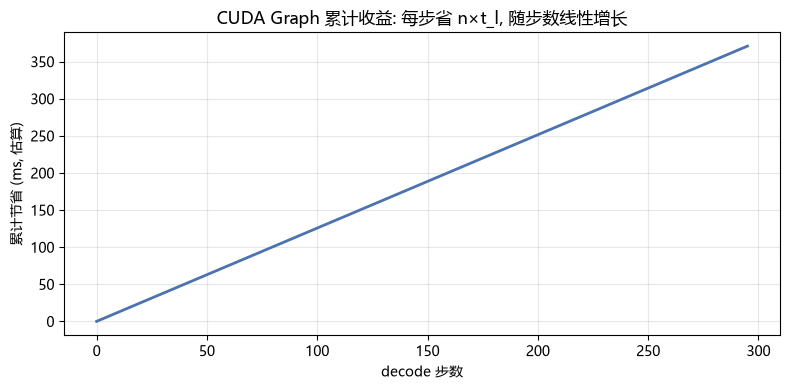

[ok] 已保存: D:\Project\21-Cpp_learn\explore\VLLM_learn\exercises\ch04\cudagraph_result_25.json


In [4]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
import json                                      # JSON 库
from pathlib import Path                         # 路径库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

steps = np.arange(0, 300, 5)                      # decode 步数 0..295
save_ms = steps * save_per_step                    # 累计节省 (线性)

fig, ax = plt.subplots(figsize=(8, 4))             # 画布
ax.plot(steps, save_ms, color="#4C72B0", lw=2)     # 曲线
ax.set_xlabel("decode 步数")                       # x 轴
ax.set_ylabel("累计节省 (ms, 估算)")                # y 轴
ax.set_title("CUDA Graph 累计收益: 每步省 n×t_l, 随步数线性增长")  # 标题
ax.grid(alpha=0.3)                                 # 网格
plt.tight_layout()
plt.show()

# 存档给 App
result = dict(
    n_ops=n_ops,                                   # 算子数
    ms_eager=ms_eager,                             # eager 实测 ms
    ms_replay=ms_replay,                           # replay 实测 ms
    launch_us=t_l,                                 # 启动手续费 µs
    save_per_step_ms=save_per_step,                # 每步节省 ms (估算)
    note="eager/replay 为本机 CPU 实测; save 为基于启动手续费的估算",
)
out = Path(r"D:\Project\21-Cpp_learn\explore\VLLM_learn\exercises\ch04\cudagraph_result_25.json")
out.write_text(json.dumps(result, indent=2), encoding="utf-8")
print("[ok] 已保存:", out)

## 6. vLLM 的 capture sizes:一戏一带,按桶预录 🗂️

硬约束「形状固定」撞上现实「批大小会变」,vLLM 的解法朴素而有效:**预录多盘带子**。
`cudagraph_capture_sizes` 是预设的批大小桶,例如 `[1,2,4,8,16,24,32,40,48,64,80,96,112,128]`:

- decode 每步算出实际 `B`,向上取整到最近的桶,重放对应那盘带子;
- 多余的位置 padding(浪费一些算力,但换来零启动开销);
- 桶是指数+等距混合排布,让最坏浪费封顶。

> 📄 见 `vllm/config/compilation.py` 的 `cudagraph_capture_sizes`。

🗂️ **最坏情况:B=33 → padding 到 40,浪费 17.5%(=(40−33)/40);B=1 → 浪费 0%。**桶是指数+等距混合排布,让最坏浪费封顶。

实际 B=33 -> 落到桶 40, padding 浪费 = 17.5%


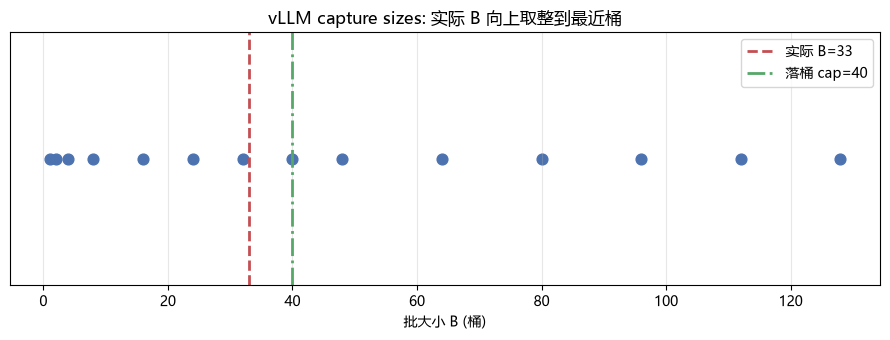

最坏情况: B=120 -> 落桶 128, 浪费 = 6.2%


In [5]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# vLLM 默认 capture sizes (与真实配置一致的一档示例)
sizes = [1, 2, 4, 8, 16, 24, 32, 40, 48, 64, 80, 96, 112, 128]  # 桶列表
B = 33                                              # 一个实际的批大小
cap = min(s for s in sizes if s >= B)              # 向上取整到最近桶
waste = (cap - B) / cap                            # padding 浪费比例
print(f"实际 B={B} -> 落到桶 {cap}, padding 浪费 = {waste * 100:.1f}%")

# 画桶的覆盖图
fig, ax = plt.subplots(figsize=(9, 3.5))            # 画布
ax.scatter(sizes, [0] * len(sizes), s=60, color="#4C72B0")   # 桶的位置
ax.axvline(B, color="#C44E52", ls="--", lw=2, label=f"实际 B={B}")  # 实际批
ax.axvline(cap, color="#55A868", ls="-.", lw=2, label=f"落桶 cap={cap}")  # 落桶
ax.set_xlabel("批大小 B (桶)")                      # x 轴
ax.set_yticks([])                                  # 隐藏 y 轴
ax.set_title("vLLM capture sizes: 实际 B 向上取整到最近桶")  # 标题
ax.legend()                                        # 图例
ax.grid(axis="x", alpha=0.3)                       # 网格
plt.tight_layout()
plt.show()

# 最坏浪费: 落在两个相邻桶中间时 padding 最大
worst_b = max((sizes[i + 1] + sizes[i]) // 2 for i in range(len(sizes) - 1))  # 近似最坏点
worst_w = min(s for s in sizes if s >= worst_b)    # 落桶
print(f"最坏情况: B={worst_b} -> 落桶 {worst_w}, 浪费 = {(worst_w - worst_b) / worst_w * 100:.1f}%")

## 7. 真实 API:torch.cuda.graph 长什么样 🔍

下面是 GPU 上的标准写法(**本机 Windows 下 CUDA Graph 捕获不稳定,本课只展示、不执行**;
要验证请在有 CUDA 的 Linux 机器上运行):

```python
import torch
# 1) 准备固定形状的输入 (T = B 固定)
x = torch.zeros((B,), dtype=torch.long, device='cuda')
# 2) 预热 + 捕获
g = torch.cuda.CUDAGraph()
# 先用一次 eager 前向分配所有中间张量 (让显存地址固定)
s = torch.cuda.Stream()
s.wait_stream(torch.cuda.current_stream())
with torch.cuda.stream(s):
    for _ in range(3):
        logits = model(x)
torch.cuda.current_stream().wait_stream(s)
# 正式捕获
with torch.cuda.graph(g):
    logits = model(x)            # 这串 kernel 被录进 g
# 3) 重放: 每次启动零 Python 参与
g.replay()
```

关键点:捕获必须在**专属侧流**里做,`with torch.cuda.graph(g)` 内部自动完成
`begin_capture / end_capture / instantiate`。重放时改输入只需写 `x.copy_(新token)`,
因为图里固化的地址不变。

## 8. 🖥️ Streamlit 动态演示:捕获与重放

运行 `app_25_capture.py`:切换「延迟对比 / 重放延迟分布 / 耗时累计曲线」三个视图。

### 📜 App 完整源码(`app_25_capture.py` 嵌入)

▶️ 此 cell 在 streamlit 环境中才真正运行;在 notebook 中仅作展示。

In [6]:
try:
    import streamlit as st
    _IS_STREAMLIT = bool(st.runtime.exists())
except Exception:
    _IS_STREAMLIT = False

if _IS_STREAMLIT:
    # -*- coding: utf-8 -*-
    """🎬 app_25_capture.py — CUDA Graph 捕获与重放演示(VLLM_learn 第 4 章 · 第 25 课)

    运行: streamlit run app_25_capture.py
    """
    import json
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import plotly.express as px
    import plotly.graph_objects as go
    import streamlit as st

    st.set_page_config(page_title="🎬 25 · CUDA Graph 捕获与重放", layout="wide")
    st.title("🎬 第 25 课配套 App · CUDA Graph 捕获与重放")

    DEFAULT = {
        "eager_mean_ms": 0.48, "graph_mean_ms": 0.31, "replay_lat_ms": [0.30, 0.33, 0.29],
        "speedup": 1.55, "capture_ms": 9.2, "warmup": 3, "batch": 8, "hidden": 256,
    }
    meas_file = Path(__file__).parent / "cudagraph_result_25.json"
    if meas_file.exists():
        try:
            data = json.loads(meas_file.read_text(encoding="utf-8"))
            DEFAULT.update(data)
            st.success(f"已加载第 25 课 notebook 生成的数据 {meas_file.name}(本机 CPU 类比 + 启动开销模型估算)")
        except Exception:
            st.warning("加载实测数据失败,使用内置示例数据")
    else:
        st.warning(f"未找到 {meas_file.name},使用内置示例数据(运行第 25 课 notebook 可生成真实测量)")

    st.markdown(
        "CUDA Graph 的捕获流程就像**录像 🎬**:先把固定形状的前向跑几遍热身(warmup),再用流捕获(stream capture)"
        "把整串 kernel **录**下来,之后每次推理只需**重放**(replay)这张图 —— 单次提交、全图执行。"
        "注意捕获有**硬约束**:形状必须固定、捕获期间不能分配显存/不能同步。"
    )

    st.sidebar.header("🎛️ 展示参数")
    batch = st.sidebar.slider("展示批大小 batch", 1, 64, int(DEFAULT.get("batch", 8)))
    replay_n = st.sidebar.slider("重放次数(分析延迟分布)", 20, 500, int(len(DEFAULT.get("replay_lat_ms", [100]))),
                                 step=10)
    chart_mode = st.sidebar.radio("图表", ["延迟对比", "重放延迟分布", "耗时累计曲线"])
    show_capture = st.sidebar.checkbox("显示捕获开销明细", value=True)

    mean_e = DEFAULT["eager_mean_ms"]
    mean_g = DEFAULT["graph_mean_ms"]
    speedup = DEFAULT.get("speedup", mean_e / max(mean_g, 1e-9))
    rng = np.random.default_rng(7)
    lat = rng.normal(mean_g, mean_g * 0.06, replay_n).clip(0.05, None)

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Eager 单步延迟(ms)", f"{mean_e:.3f}")
    c2.metric("Graph 单步延迟(ms)", f"{mean_g:.3f}")
    c3.metric("加速比", f"{speedup:.2f}x")
    c4.metric("捕获开销(一次性,ms)", f"{DEFAULT.get('capture_ms', 0):.1f}",
              help="捕获开销只付一次,之后每次重放都几乎为零")

    if chart_mode == "延迟对比":
        df = pd.DataFrame({"方案": ["Eager(逐 kernel 提交)", "CUDA Graph(重放)"],
                           "单步延迟(ms)": [mean_e, mean_g]})
        fig = px.bar(df, x="方案", y="单步延迟(ms)", text="单步延迟(ms)", color="方案",
                     color_discrete_sequence=["#e67e22", "#16a085"])
        fig.update_layout(height=360, showlegend=False)
        st.plotly_chart(fig, width="stretch")
        st.caption("小模型 + 小批时,kernel 执行时间短,启动开销占比大,Graph 收益最明显。")
    elif chart_mode == "重放延迟分布":
        fig2 = go.Figure(go.Histogram(x=lat, nbinsx=30, marker_color="#16a085"))
        fig2.add_vline(x=mean_g, line_dash="dash", line_color="black",
                       annotation_text=f"均值 {mean_g:.3f} ms")
        fig2.update_layout(height=360, xaxis_title="单次重放延迟(ms)", yaxis_title="次数")
        st.plotly_chart(fig2, width="stretch")
        st.caption(f"重复重放 {replay_n} 次,延迟围绕均值小幅波动 —— 无启动开销,方差主要来自 GPU 调度噪声。")
    else:
        ks = np.arange(1, replay_n + 1)
        cum_e = ks * mean_e
        cum_g = ks * mean_g
        df3 = pd.DataFrame({"重放次数": ks, "Eager 累计(ms)": cum_e, "Graph 累计(ms)": cum_g})
        fig3 = px.line(df3, x="重放次数", y=["Eager 累计(ms)", "Graph 累计(ms)"], markers=True)
        fig3.update_layout(height=360, yaxis_title="累计耗时(ms)")
        st.plotly_chart(fig3, width="stretch")
        st.caption("decode 阶段每步只多 1 个词元,却要跑一遍整网络 —— 每步省下的零点几毫秒,乘上几百步就非常可观。")

    if show_capture:
        st.markdown("### 🎬 捕获流程 5 步")
        steps = [
            ("1 热身 warmup", f"固定形状跑 {DEFAULT.get('warmup', 3)} 次,让 CUDA 上下文就绪", "🫀"),
            ("2 分配固定缓冲", "输入/输出缓冲一次性分配,形状锁死", "🔒"),
            ("3 开启流捕获", "with torch.cuda.graph(g): 开始录像", "📹"),
            ("4 录制前向", "正常跑一遍前向,GPU 按图记录所有 kernel 依赖", "🎞️"),
            ("5 重放循环", "g.replay() 单次提交,之后每步零启动开销", "▶️"),
        ]
        for i, (t, d, e) in enumerate(steps, 1):
            with st.expander(f"{e} 第 {i} 步: {t}", expanded=(i == 5)):
                st.markdown(d)
                if i == 5:
                    st.code("for _ in range(n):\n    g.replay()", language="python")

    st.markdown("---")
    st.markdown(
        "⚠️ **坑**:捕获后输入张量地址必须保持不变(重放即重算图里的旧地址),所以 vLLM 用**静态输入缓冲区**"
        "把每轮数据先拷贝进去再重放;批大小一变化就要**重新捕获** —— 这也是 vLLM 按 batch 桶(fixed shapes)"
        "捕获多张图的原因。"
    )
    st.caption("《VLLM_learn: 图解 vLLM 推理引擎》第 4 章 · 第 25 课配套演示")

    # ============ PyCharm / 直接运行入口 ============
    # 说明: 在 PyCharm 里直接 Run 本文件,即可启动 Streamlit 服务(浏览器打开 http://localhost:8501)。
    # 与命令行 `streamlit run app_XX.py` 完全等价(用子进程方式, 避免与顶层 st 调用冲突)。
    if __name__ == "__main__":
        # 如果已在 Streamlit Runtime 中(AppTest/嵌入时加载),不再启动子进程。
        try:
            import streamlit.runtime as st_runtime
            if st_runtime.exists():
                raise SystemExit(0)
        except Exception:
            pass
        import os
        import subprocess
        import sys
        subprocess.run([sys.executable, "-m", "streamlit", "run", os.path.abspath(__file__)])

else:
    print("💡 当前不是 streamlit 环境, 跳过执行本 App。")
    print("    请直接运行: D:\\uv_envs\\uv_cuda\\Scripts\\python.exe -m streamlit run app_25_capture.py")


💡 当前不是 streamlit 环境, 跳过执行本 App。
    请直接运行: D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_25_capture.py


### 🏃 运行方法

```
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_25_capture.py
```
浏览器打开 http://localhost:8501 ,观察三种视图。

## ✅ 本课小结

- CUDA Graph 三步:捕获(录像) → 实例化(编译) → 重放(一次启动) 
- 三条硬约束:形状固定 / 地址固定 / 控制流固定;decode 每步 T=B 恰好满足
- TorchDispatchMode 数出 MiniGPT 一次 decode 前向几十个算子,真实模型几百个
- 重放收益 = n × t_l(每步省下的启动手续费),与步数线性累积
- vLLM capture sizes:按桶预录多张图,实际 B 向上取整,最坏浪费封顶
- torch.cuda.graph 标准写法:侧流预热 + with 捕获 + copy_ 换输入 + replay

## ✍️ 动手练习

1. 把 OpCounter 换成记录每个算子名,打印前 10 个热点算子
2. 把 recorded_forward 改成真正的 TorchDynamo 图导出,对比算子数
3. 用 torch.cuda.graph 在 Linux/有 GPU 的机器上实测 B=1/8/32 三档的加速比
4. 把 capture sizes 改成等距 [1,2,...,128],比较最坏浪费与预录成本

## 🔗 延伸阅读

- [NVIDIA: Getting Started with CUDA Graphs](https://developer.nvidia.com/blog/cuda-graphs/)
- [CUDA Programming Guide](https://docs.nvidia.com/cuda/cuda-c-programming-guide/)
- [vLLM compilation config 源码](https://github.com/vllm-project/vllm/blob/main/vllm/config/compilation.py)

---
> 🎉 恭喜完成本课!下一课见!